# Composer Classification of MIDI Music with LSTM and CNN Models

**Deep Learning Final Project**

This notebook develops and compares two deep learning models - a **Long Short-Term Memory (LSTM)** network and a **Convolutional Neural Network (CNN)** - that predict the composer of a MIDI musical composition. The task is restricted to four composers:

1. **Bach**
2. **Beethoven**
3. **Chopin**
4. **Mozart**

## Project overview

Each architecture receives a representation that suits it. The LSTM consumes *ordered note-pitch sequences* (an event stream), which matches its strength at modeling temporal order. The CNN consumes *piano-roll matrices* (a 2-D pitch-by-time image), which matches its strength at detecting local 2-D patterns such as chords and textures. Both models are trained, tuned, and evaluated on the same train/validation/test partition, and their results are compared directly.

## How to run this notebook

**Local Jupyter:**
1. Make sure the `dataset_4composers` folder is available at `build/datasets/dataset_4composers` (relative to this notebook). It must contain one sub-folder per composer: `Bach/`, `Beethoven/`, `Chopin/`, `Mozart/`.
2. Run the *Setup* cells to install libraries.
3. Run the notebook top to bottom.

Everything is CPU-compatible; a GPU only speeds up training.

> **Reproducibility & honesty note.** All metrics, tables, and figures in this notebook are produced by the code at run time. Nothing is hard-coded. Cells that print final numbers are marked so you can copy the printed values into the report. If a step cannot run (for example, the dataset is missing), the code fails loudly with a clear message rather than silently continuing.


## 1. Setup: install and import libraries

The next cell installs the third-party libraries the notebook needs (`pretty_midi` and `music21` are usually not pre-installed). The install cell is safe to re-run.

In [2]:
# Must run before any TensorFlow import so env vars and CUDA libs are in place
import os, sys

# Prepend notebook directory so utilsTF.py is importable
sys.path.insert(0, os.path.dirname(os.path.abspath("FirstPass.ipynb")))

from utilsTF import load_cuda_libraries, configure_tensorflow

load_cuda_libraries()      # pre-load nvidia .so files into process memory
configure_tensorflow()     # set XLA_FLAGS and TF_CPP_MIN_LOG_LEVEL before TF loads

2026-07-20 15:37:46.734653: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-20 15:38:01.651560: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


✓ Loaded CUDA libraries from /home/maxim/miniconda3/envs/511-team-project-2/lib/python3.11/site-packages/nvidia


In [3]:
from utilsTF import test_gpu

test_gpu()   # enable memory growth and report available GPUs

✓ GPU setup complete - 1 GPU(s) available


2026-07-20 15:38:43.751947: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-07-20 15:38:43.752180: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-07-20 15:38:43.752252: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


1

In [4]:
# --- Imports ---
import os, re, glob, hashlib, random, warnings, collections
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# MIDI parsing (with graceful failure if unavailable)
try:
    import pretty_midi
except ImportError as e:
    raise ImportError(
        "pretty_midi is required. Run the install cell above, then restart the "
        "runtime and re-run."
    ) from e

# Deep learning
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers

# Metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_fscore_support, accuracy_score)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")
pretty_midi.pretty_midi.MAX_TICK = 1e7  # tolerate long files without warnings
sns.set_context("notebook")
print("TensorFlow version:", tf.__version__)
print("GPU available:", bool(tf.config.list_physical_devices("GPU")))

TensorFlow version: 2.16.1
GPU available: True


## 2. Configuration and random seeds

All tunable constants live here so the notebook has a single control panel. `DATASET_PATH` is the **only** path you normally need to change. Random seeds are fixed for NumPy, Python, and TensorFlow so runs are reproducible (small non-determinism can still occur on GPU).

In [5]:
# ----------------------------- CONFIG --------------------------------------
# dataset_4composers: flat layout with one sub-folder per composer.
# Update this path to wherever dataset_4composers lives on your machine.
DATASET_PATH = "build/datasets/dataset_4composers"

TARGET_COMPOSERS = ["Bach", "Beethoven", "Chopin", "Mozart"]

# LSTM (note-sequence) settings
SEQ_LEN      = 100        # notes per training window
SEQ_STRIDE   = 50         # hop between windows (controls overlap / augmentation)
PITCH_VOCAB  = 128        # MIDI pitches 0-127
PAD_TOKEN    = 128        # reserved padding index -> embedding input_dim = 129

# CNN (piano-roll) settings
PR_FS        = 8          # piano-roll sampling frequency (frames per second)
PR_TIME      = 128        # time frames per window
PR_PITCH     = 128        # pitch rows (fixed by MIDI)
PR_STRIDE    = 64         # hop between piano-roll windows

# Split / training settings
TEST_SIZE    = 0.15
VAL_SIZE     = 0.15       # fraction of the WHOLE dataset (taken from train remainder)
BATCH_SIZE   = 64
MAX_EPOCHS   = 60
PATIENCE     = 8
SEED         = 42

# Data-augmentation (training split only)
AUG_TRANSPOSITIONS = [-2, -1, 1, 2]   # semitone shifts; [] disables transposition

# Optional caps to keep runtime reasonable on limited hardware.
# MAX_FILES_PER_COMPOSER caps RAM usage: the dataset_4composers has up to 1024
# files for Bach alone; without a cap the fully-materialized CNN array would
# exceed 10 GB in WSL.  50 files/composer keeps peak RAM under ~1 GB (matching
# the scale of the original NN_midi_files_extended dataset).
MAX_FILES_PER_COMPOSER   = 75
MAX_WINDOWS_PER_FILE     = 20

# Output directories — created automatically on first run.
ARTIFACTS_DIR     = Path("build/artifacts")      # model checkpoints + training histories
VISUALIZATIONS_DIR = Path("build/visualizations") # CSVs and exported figures
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
VISUALIZATIONS_DIR.mkdir(parents=True, exist_ok=True)
# ---------------------------------------------------------------------------

def set_seeds(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed); np.random.seed(seed); tf.random.set_seed(seed)

set_seeds()
LABEL2IDX = {c: i for i, c in enumerate(TARGET_COMPOSERS)}
IDX2LABEL = {i: c for c, i in LABEL2IDX.items()}
print("Label encoding:", LABEL2IDX)

Label encoding: {'Bach': 0, 'Beethoven': 1, 'Chopin': 2, 'Mozart': 3}


## 3. Dataset loading

**Dataset:** *midi-classic-music* by Bohdan Fedorak (Kaggle, 2019) — pre-filtered to four composers and stored locally as `dataset_4composers`. The directory has a **flat layout**: one sub-folder per composer (`Bach/`, `Beethoven/`, `Chopin/`, `Mozart/`) containing `.mid` files directly, with no pre-defined train/val/test split.

The data lives in the repository at `build/datasets/dataset_4composers`. The cell below verifies the directory layout and reports file counts per composer. A **50-file-per-composer cap** is applied before splitting to keep peak RAM under ~1.5 GB; the full corpus contains 1,637 files but materializing all piano-roll windows would exceed 10 GB.

In [6]:
# --- Verify the dataset directory layout -------------------------------------
if not os.path.isdir(DATASET_PATH):
    raise FileNotFoundError(
        f"DATASET_PATH does not exist: {DATASET_PATH}\n"
        "Set DATASET_PATH in the CONFIG cell to the folder that contains the "
        "composer sub-folders (Bach/, Beethoven/, Chopin/, Mozart/).")

print(f"Dataset root: {os.path.abspath(DATASET_PATH)}")
print(f"Composers ({len(TARGET_COMPOSERS)}): {TARGET_COMPOSERS}\n")

for comp in TARGET_COMPOSERS:
    comp_dir = Path(DATASET_PATH) / comp
    if comp_dir.is_dir():
        n = sum(1 for ext in ("*.mid", "*.midi", "*.MID", "*.MIDI")
                for _ in comp_dir.rglob(ext))
        print(f"  {comp:12s}: {n} MIDI files")
    else:
        print(f"  {comp:12s}: folder not found at {comp_dir}")

Dataset root: /mnt/d/Documents/MachineLearning/TeamProject-511/build/datasets/dataset_4composers
Composers (4): ['Bach', 'Beethoven', 'Chopin', 'Mozart']

  Bach        : 1024 MIDI files
  Beethoven   : 220 MIDI files
  Chopin      : 136 MIDI files
  Mozart      : 257 MIDI files


## 4. Dataset inspection, filtering, and label creation

The dataset layout is flat: `<composer>/<file>.mid`. The code **walks `DATASET_PATH` recursively**, collects every `.mid`/`.midi` file, and infers the composer from the file path — a file is kept only if exactly one of the four target composer names appears in its path (the exactly-one-match rule rejects ambiguous files). This step also performs **de-duplication by MD5 hash** and drops files that are unreadable or too short to yield a training window.

In [7]:
def infer_composer(path, targets=TARGET_COMPOSERS):
    """Return the single matching target composer found in the path, or None."""
    matches = [c for c in targets if c.lower() in str(path).lower()]
    return matches[0] if len(matches) == 1 else None

def collect_midi_files(root, composers=TARGET_COMPOSERS):
    """Recursively walk root, infer composer from path, return one record per file."""
    records = []
    for ext in ("*.mid", "*.midi", "*.MID", "*.MIDI"):
        for f in Path(root).rglob(ext):
            comp = infer_composer(f, composers)
            if comp is not None:
                records.append({"path": str(f), "composer": comp})
    return (pd.DataFrame(records)
              .drop_duplicates(subset="path")
              .sort_values("path")
              .reset_index(drop=True))

raw_df = collect_midi_files(DATASET_PATH)
if len(raw_df) == 0:
    raise RuntimeError("No MIDI files found. Check DATASET_PATH and the dataset contents.")

print(f"Files matching the four target composers: {len(raw_df)}")
print("\nRaw counts per composer (before cleaning):")
print(raw_df["composer"].value_counts())

Files matching the four target composers: 1637

Raw counts per composer (before cleaning):
composer
Bach         1024
Mozart        257
Beethoven     220
Chopin        136
Name: count, dtype: int64


In [8]:
# --- De-duplicate by content hash and drop unreadable files ------------------
def md5_of(path, chunk=1 << 20):
    h = hashlib.md5()
    with open(path, "rb") as fh:
        for block in iter(lambda: fh.read(chunk), b""):
            h.update(block)
    return h.hexdigest()

raw_df["md5"] = raw_df["path"].map(md5_of)
before = len(raw_df)
dedup_df = raw_df.drop_duplicates(subset="md5").reset_index(drop=True)
print(f"Duplicate files removed: {before - len(dedup_df)}")

# Validate that each file is parseable; record note counts.
def probe_midi(path):
    try:
        pm = pretty_midi.PrettyMIDI(path)
        n_notes = sum(len(inst.notes) for inst in pm.instruments)
        return n_notes
    except Exception:
        return -1   # unreadable / invalid

dedup_df["n_notes"] = dedup_df["path"].map(probe_midi)
unreadable = int((dedup_df["n_notes"] < 0).sum())
empty      = int((dedup_df["n_notes"] == 0).sum())
print(f"Unreadable / invalid MIDI files: {unreadable}")
print(f"Readable but empty (no notes):   {empty}")

# Keep only files with a usable number of notes for at least one window.
clean_df = dedup_df[dedup_df["n_notes"] >= SEQ_LEN].reset_index(drop=True)
print(f"\nUsable files (>= {SEQ_LEN} notes): {len(clean_df)}")
print("\nUsable counts per composer (after cleaning):")
print(clean_df["composer"].value_counts())

Duplicate files removed: 21
Unreadable / invalid MIDI files: 2
Readable but empty (no notes):   0

Usable files (>= 100 notes): 1611

Usable counts per composer (after cleaning):
composer
Bach         1012
Mozart        254
Beethoven     213
Chopin        132
Name: count, dtype: int64


### 4.1 Before/after summary and class distribution

The table below reports usable file counts per composer **before and after** preprocessing, satisfying the requirement to document data availability explicitly. The bar chart visualizes class balance; any strong imbalance is addressed later with class weights during training.

File counts per composer:

           raw_matched  after_dedup  usable
composer                                   
Bach              1024         1014    1012
Beethoven          220          215     213
Chopin             136          132     132
Mozart             257          255     254
TOTAL             1637         1616    1611


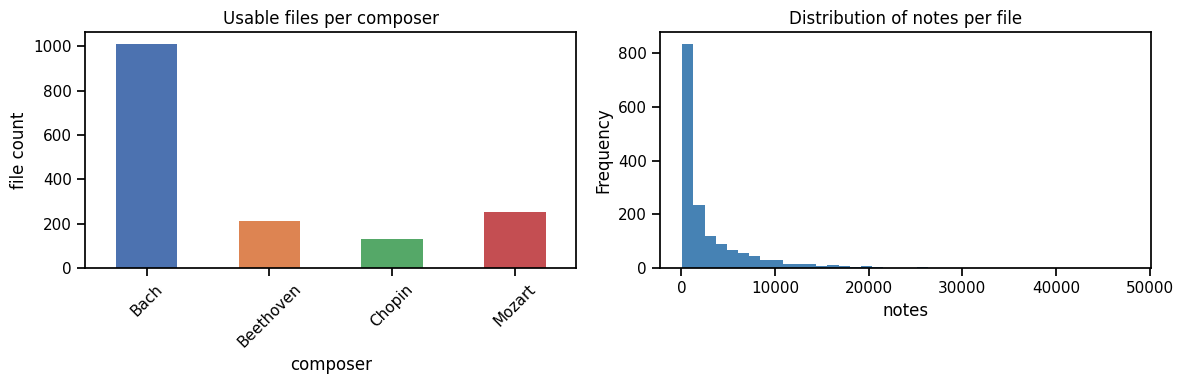

In [9]:
summary = (pd.DataFrame({
        "raw_matched": raw_df["composer"].value_counts(),
        "after_dedup": dedup_df["composer"].value_counts(),
        "usable":      clean_df["composer"].value_counts(),
    })
    .reindex(TARGET_COMPOSERS)
    .fillna(0).astype(int))
summary.loc["TOTAL"] = summary.sum()
print("File counts per composer:\n")
print(summary)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
clean_df["composer"].value_counts().reindex(TARGET_COMPOSERS).plot(
    kind="bar", ax=ax[0], color=sns.color_palette("deep", len(TARGET_COMPOSERS)))
ax[0].set_title("Usable files per composer"); ax[0].set_ylabel("file count")
ax[0].tick_params(axis="x", rotation=45)
clean_df["n_notes"].plot(kind="hist", bins=40, ax=ax[1], color="steelblue")
ax[1].set_title("Distribution of notes per file"); ax[1].set_xlabel("notes")
plt.tight_layout(); plt.show()

## 5. Train / validation / test splitting (leakage-safe)

The split is performed **at the file level, before any windowing**, using a stratified 70/15/15 train/val/test partition. Splitting whole files first guarantees that every window from a given composition stays inside a single split — windows from one piece can never land in both training and test sets, which would let the model memorize a piece rather than a composer's style. The 50-file-per-composer cap is applied before splitting so each composer is equally represented in every split. The MD5 de-duplication from Section 4 additionally guarantees that no identical file appears in two splits, and the assertion below verifies it.

In [10]:
files_all = clean_df["path"].values
labels_all = clean_df["composer"].map(LABEL2IDX).values

# Per-composer cap applied BEFORE splitting so every split benefits equally.
# This is the primary guard against WSL memory explosion: at 50 files/composer,
# 4 composers × 50 files × 20 windows × 5 augmentations = 20,000 CNN windows
# ≈ 1.3 GB — well within WSL limits.
if MAX_FILES_PER_COMPOSER is not None:
    keep_idx = []
    rng = np.random.RandomState(SEED)
    for c in range(len(TARGET_COMPOSERS)):
        idx = np.where(labels_all == c)[0]
        rng.shuffle(idx)
        keep_idx.extend(idx[:MAX_FILES_PER_COMPOSER])
    keep_idx = np.array(sorted(keep_idx))
    files_all, labels_all = files_all[keep_idx], labels_all[keep_idx]

# Stratified split: first carve out test, then split remainder into train/val.
f_trainval, f_test, y_trainval, y_test = train_test_split(
    files_all, labels_all, test_size=TEST_SIZE, stratify=labels_all, random_state=SEED)
val_relative = VAL_SIZE / (1.0 - TEST_SIZE)
f_train, f_val, y_train, y_val = train_test_split(
    f_trainval, y_trainval, test_size=val_relative,
    stratify=y_trainval, random_state=SEED)

print(f"Files -> train: {len(f_train)}  val: {len(f_val)}  test: {len(f_test)}")
for name, y in [("train", y_train), ("val", y_val), ("test", y_test)]:
    dist = {IDX2LABEL[i]: int((y == i).sum()) for i in range(len(TARGET_COMPOSERS))}
    print(f"  {name:5s} class counts: {dist}")

# Sanity check: no file appears in more than one split.
assert set(f_train) & set(f_test) == set()
assert set(f_train) & set(f_val)  == set()
assert set(f_val)   & set(f_test) == set()
print("Leakage check passed: splits are disjoint at the file level.")

Files -> train: 210  val: 45  test: 45
  train class counts: {'Bach': 53, 'Beethoven': 53, 'Chopin': 52, 'Mozart': 52}
  val   class counts: {'Bach': 11, 'Beethoven': 11, 'Chopin': 11, 'Mozart': 12}
  test  class counts: {'Bach': 11, 'Beethoven': 11, 'Chopin': 12, 'Mozart': 11}
Leakage check passed: splits are disjoint at the file level.


## 6. Feature extraction

Two representations are extracted from the **same** MIDI files, one tailored to each model.

**LSTM - note-pitch sequences.** Every note across all instruments is sorted by onset time, and its MIDI pitch (0-127) becomes a token. The stream is cut into overlapping windows of `SEQ_LEN` notes (hop `SEQ_STRIDE`). Ordered pitch tokens preserve melodic and harmonic motion over time, which is what a recurrent network is built to model. An `Embedding` layer turns each pitch token into a learned dense vector.

**CNN - piano-roll windows.** `pretty_midi.get_piano_roll(fs=PR_FS)` produces a 128 x time matrix of note activity. It is binarized and cut into `PR_PITCH` x `PR_TIME` windows (hop `PR_STRIDE`). A piano roll is effectively an image of the music, so 2-D convolutions can pick up chords (vertical structure) and rhythmic/melodic motifs (horizontal structure).

Because both representations are windowed, one file yields several samples - a form of **sequence-window augmentation** that also enlarges the dataset.

In [11]:
def extract_note_sequence(path):
    """Return a 1-D array of pitch tokens ordered by onset time, or None."""
    try:
        pm = pretty_midi.PrettyMIDI(path)
    except Exception:
        return None
    notes = [(n.start, n.pitch) for inst in pm.instruments
             if not inst.is_drum for n in inst.notes]
    if len(notes) < SEQ_LEN:
        return None
    notes.sort(key=lambda x: x[0])
    return np.array([p for _, p in notes], dtype=np.int16)

def sequence_windows(seq, seq_len=SEQ_LEN, stride=SEQ_STRIDE, cap=MAX_WINDOWS_PER_FILE):
    out = []
    for start in range(0, len(seq) - seq_len + 1, stride):
        out.append(seq[start:start + seq_len])
        if cap is not None and len(out) >= cap:
            break
    return out

def extract_piano_roll(path):
    """Return a binarized 128 x time piano roll, or None."""
    try:
        pm = pretty_midi.PrettyMIDI(path)
    except Exception:
        return None
    if len(pm.instruments) == 0:
        return None
    roll = pm.get_piano_roll(fs=PR_FS)            # (128, T) velocity
    if roll.shape[1] < PR_TIME:
        return None
    return (roll > 0).astype(np.float32)          # binarize

def roll_windows(roll, t=PR_TIME, stride=PR_STRIDE, cap=MAX_WINDOWS_PER_FILE):
    out = []
    for start in range(0, roll.shape[1] - t + 1, stride):
        out.append(roll[:, start:start + t])
        if cap is not None and len(out) >= cap:
            break
    return out

print("Feature-extraction helpers defined.")

Feature-extraction helpers defined.


### 6.1 Build windowed datasets per split

The helper below turns a list of files into arrays of windows plus matching labels. **Augmentation (pitch transposition) is applied to the training split only**; validation and test windows are never augmented, preserving an honest estimate of generalization. Transposition by a few semitones changes key but preserves intervals and contour, so the composer's style is retained.

In [12]:
def transpose_sequence(seq, shift):
    out = seq.astype(np.int16) + shift
    out = np.clip(out, 0, PITCH_VOCAB - 1)
    return out

def transpose_roll(roll, shift):
    out = np.zeros_like(roll)
    if shift == 0:
        return roll
    if shift > 0:
        out[shift:, :] = roll[:-shift, :]
    else:
        out[:shift, :] = roll[-shift:, :]
    return out

def build_sequence_split(files, labels, augment=False):
    X, y = [], []
    skipped = 0
    for path, lab in zip(files, labels):
        seq = extract_note_sequence(path)
        if seq is None:
            skipped += 1
            continue
        for w in sequence_windows(seq):
            X.append(w); y.append(lab)
            if augment:
                for s in AUG_TRANSPOSITIONS:
                    X.append(transpose_sequence(w, s)); y.append(lab)
    return np.array(X, dtype=np.int32), np.array(y, dtype=np.int32), skipped

def build_roll_split(files, labels, augment=False):
    X, y = [], []
    skipped = 0
    for path, lab in zip(files, labels):
        roll = extract_piano_roll(path)
        if roll is None:
            skipped += 1
            continue
        for w in roll_windows(roll):
            X.append(w); y.append(lab)
            if augment:
                for s in AUG_TRANSPOSITIONS:
                    X.append(transpose_roll(w, s)); y.append(lab)
    X = np.array(X, dtype=np.float32)
    if X.ndim == 3:
        X = X[..., np.newaxis]          # add channel dim -> (N, 128, PR_TIME, 1)
    return X, np.array(y, dtype=np.int32), skipped

print("Split builders defined.")

Split builders defined.


In [13]:
# ---- LSTM sequence datasets ----
Xseq_train, yseq_train, sk1 = build_sequence_split(f_train, y_train, augment=True)
Xseq_val,   yseq_val,   sk2 = build_sequence_split(f_val,   y_val,   augment=False)
Xseq_test,  yseq_test,  sk3 = build_sequence_split(f_test,  y_test,  augment=False)
print("LSTM (note-sequence) windows")
print(f"  train: {Xseq_train.shape}  val: {Xseq_val.shape}  test: {Xseq_test.shape}")
print(f"  files skipped (train/val/test): {sk1}/{sk2}/{sk3}")

# ---- CNN piano-roll datasets ----
Xcnn_train, ycnn_train, sk4 = build_roll_split(f_train, y_train, augment=True)
Xcnn_val,   ycnn_val,   sk5 = build_roll_split(f_val,   y_val,   augment=False)
Xcnn_test,  ycnn_test,  sk6 = build_roll_split(f_test,  y_test,  augment=False)
print("\nCNN (piano-roll) windows")
print(f"  train: {Xcnn_train.shape}  val: {Xcnn_val.shape}  test: {Xcnn_test.shape}")
print(f"  files skipped (train/val/test): {sk4}/{sk5}/{sk6}")

LSTM (note-sequence) windows
  train: (17620, 100)  val: (726, 100)  test: (732, 100)
  files skipped (train/val/test): 0/0/0

CNN (piano-roll) windows
  train: (16585, 128, 128, 1)  val: (676, 128, 128, 1)  test: (680, 128, 128, 1)
  files skipped (train/val/test): 0/0/0


### 6.2 Window-level class distribution and class weights

Windowing can change class balance because some composers have longer pieces (more windows). The counts below reflect the **actual training signal**. Class weights are computed from the training windows and passed to both models so that minority composers are not ignored.

Window counts per class
LSTM train: {'Bach': 3185, 'Beethoven': 4970, 'Chopin': 4720, 'Mozart': 4745}
CNN  train: {'Bach': 2810, 'Beethoven': 4985, 'Chopin': 3995, 'Mozart': 4795}

LSTM class weights: {'Bach': 1.383, 'Beethoven': 0.886, 'Chopin': 0.933, 'Mozart': 0.928}
CNN  class weights: {'Bach': 1.476, 'Beethoven': 0.832, 'Chopin': 1.038, 'Mozart': 0.865}


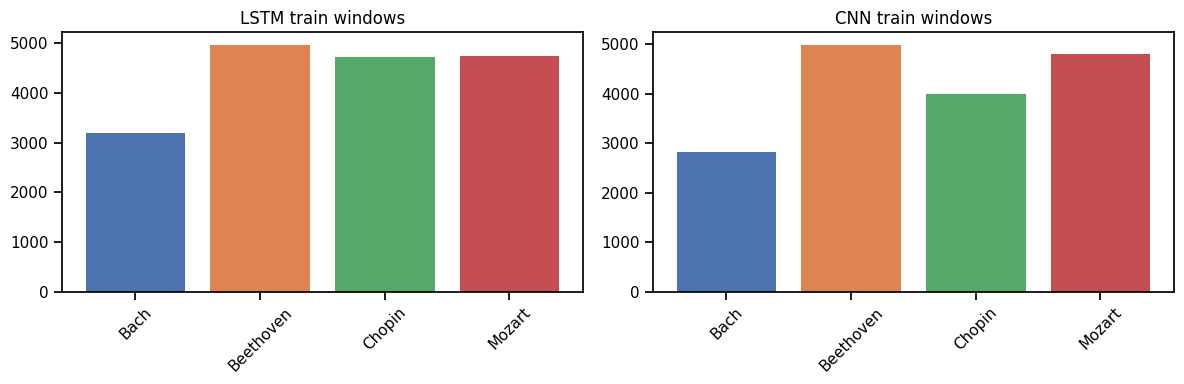

In [14]:
def show_distribution(y, title):
    counts = {IDX2LABEL[i]: int((y == i).sum()) for i in range(len(TARGET_COMPOSERS))}
    print(f"{title}: {counts}")
    return counts

print("Window counts per class")
_ = show_distribution(yseq_train, "LSTM train")
_ = show_distribution(ycnn_train, "CNN  train")

# Class weights (shared logic; computed separately per representation)
def class_weights(y):
    classes = np.arange(len(TARGET_COMPOSERS))
    w = compute_class_weight("balanced", classes=classes, y=y)
    return {int(c): float(wi) for c, wi in zip(classes, w)}

cw_seq = class_weights(yseq_train)
cw_cnn = class_weights(ycnn_train)
print("\nLSTM class weights:", {IDX2LABEL[k]: round(v, 3) for k, v in cw_seq.items()})
print("CNN  class weights:", {IDX2LABEL[k]: round(v, 3) for k, v in cw_cnn.items()})

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for a, (y, t) in zip(ax, [(yseq_train, "LSTM train windows"),
                          (ycnn_train, "CNN train windows")]):
    vals = [ (y == i).sum() for i in range(len(TARGET_COMPOSERS)) ]
    a.bar(TARGET_COMPOSERS, vals, color=sns.color_palette("deep", len(TARGET_COMPOSERS)))
    a.set_title(t); a.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

## 7. Model 1 - LSTM

The LSTM classifies a window of ordered pitch tokens. An `Embedding` layer maps each of the 129 possible tokens (128 pitches + 1 padding index) to a dense vector; two stacked LSTM layers model temporal dependencies; dropout regularizes; and a softmax `Dense` layer outputs a probability over the composer classes.

**Key hyperparameters:** embedding dim 64, LSTM units 128 then 64, dropout 0.3, Adam optimizer, sparse categorical cross-entropy (labels are integers). These are explained in the report.

In [15]:
def build_lstm(units1=128, units2=64, emb_dim=64, dropout=0.3, lr=1e-3):
    set_seeds()
    model = models.Sequential([
        layers.Input(shape=(SEQ_LEN,)),
        layers.Embedding(input_dim=PITCH_VOCAB + 1, output_dim=emb_dim,
                         mask_zero=False),
        layers.LSTM(units1, return_sequences=True, dropout=dropout),
        layers.LSTM(units2, dropout=dropout),
        layers.Dense(64, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(len(TARGET_COMPOSERS), activation="softmax"),
    ], name="LSTM_composer_classifier")
    model.compile(optimizer=optimizers.Adam(lr),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model

build_lstm().summary()

2026-07-20 15:41:22.404523: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-07-20 15:41:22.404651: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-07-20 15:41:22.404698: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-07-20 15:41:22.544565: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-07-20 15:41:22.544673: I external/local_xla/xla/stream_executor

Model: "LSTM_composer_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 64)        │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,900 (628.52 KB)

 Trainable params: 160,900 (628.52 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Model 2 - CNN

The CNN classifies a piano-roll window (128 pitches x `PR_TIME` frames x 1 channel). Three convolutional blocks (Conv -> BatchNorm -> MaxPool) grow the receptive field; global average pooling collapses the feature map; and a softmax `Dense` layer outputs the composer probabilities. Batch normalization and dropout provide regularization.

**Key hyperparameters:** filters 32 -> 64 -> 128, 3x3 kernels, dropout 0.3, Adam optimizer, sparse categorical cross-entropy.

In [16]:
def build_cnn(f1=32, f2=64, f3=128, dropout=0.3, lr=1e-3):
    set_seeds()
    model = models.Sequential([
        layers.Input(shape=(PR_PITCH, PR_TIME, 1)),
        layers.Conv2D(f1, 3, padding="same", activation="relu"),
        layers.BatchNormalization(), layers.MaxPooling2D(2),
        layers.Conv2D(f2, 3, padding="same", activation="relu"),
        layers.BatchNormalization(), layers.MaxPooling2D(2),
        layers.Conv2D(f3, 3, padding="same", activation="relu"),
        layers.BatchNormalization(), layers.MaxPooling2D(2),
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(len(TARGET_COMPOSERS), activation="softmax"),
    ], name="CNN_composer_classifier")
    model.compile(optimizer=optimizers.Adam(lr),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model

build_cnn().summary()

Model: "CNN_composer_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,596 (432.02 KB)

 Trainable params: 110,148 (430.27 KB)

 Non-trainable params: 448 (1.75 KB)

## 9. Training with callbacks

Both models use the same training routine: **early stopping** on validation loss (restores the best weights) and **model checkpointing** to save the best model. Class weights address imbalance. Training and validation loss/accuracy are recorded for later plotting.

In [17]:
def train_model(build_fn, Xtr, ytr, Xval, yval, class_weight, tag, **kw):
    set_seeds()
    model = build_fn(**kw)
    ckpt_path = str(ARTIFACTS_DIR / f"best_{tag}.keras")
    cbs = [
        callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE,
                                restore_best_weights=True),
        callbacks.ModelCheckpoint(ckpt_path, monitor="val_loss",
                                  save_best_only=True),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                    patience=3, min_lr=1e-5),
    ]
    history = model.fit(
        Xtr, ytr, validation_data=(Xval, yval),
        epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
        class_weight=class_weight, callbacks=cbs, verbose=2)
    # Save history alongside the model so training can be skipped later.
    import json as _json
    with open(ARTIFACTS_DIR / f"history_{tag}.json", "w") as fh:
        _json.dump(history.history, fh)
    return model, history

print("Training utility ready.")

Training utility ready.


## 10. Hyperparameter optimization

A small, honest grid search is run for each model over a few settings (learning rate and dropout). The configuration with the best **validation accuracy** is kept and later evaluated on the untouched test set. The grid is intentionally small so it finishes in a reasonable time; widen it if you have more compute.

> The printed table is produced at run time - copy its real values into the report's optimization table. No numbers are pre-filled.

In [18]:
LSTM_GRID = [
    {"lr": 1e-3, "dropout": 0.3},
    {"lr": 5e-4, "dropout": 0.3},
    {"lr": 1e-3, "dropout": 0.5},
]
CNN_GRID = [
    {"lr": 1e-3, "dropout": 0.3},
    {"lr": 5e-4, "dropout": 0.3},
    {"lr": 1e-3, "dropout": 0.5},
]

def grid_search(build_fn, grid, Xtr, ytr, Xval, yval, cw, tag):
    """Run grid search, skipping any config whose checkpoint already exists."""
    import json as _json
    rows, best = [], None
    for i, params in enumerate(grid):
        cfg_tag      = f"{tag}_cfg{i}"
        model_path   = ARTIFACTS_DIR / f"best_{cfg_tag}.keras"
        history_path = ARTIFACTS_DIR / f"history_{cfg_tag}.json"
        if model_path.exists():
            print(f"[{cfg_tag}] checkpoint found, loading from disk ...")
            model = tf.keras.models.load_model(str(model_path))
            if history_path.exists():
                with open(history_path) as fh:
                    hist_data = _json.load(fh)
            else:
                hist_data = {"val_accuracy": [0], "accuracy": [0],
                             "val_loss": [], "loss": []}
            class _H:
                history = hist_data
            hist = _H()
        else:
            model, hist = train_model(build_fn, Xtr, ytr, Xval, yval, cw,
                                      tag=cfg_tag, **params)
        val_acc = max(hist.history["val_accuracy"])
        rows.append({**params, "best_val_acc": round(val_acc, 4)})
        if best is None or val_acc > best["val_acc"]:
            best = {"val_acc": val_acc, "params": params,
                    "model": model, "history": hist}
    table = pd.DataFrame(rows)
    print(f"\n{tag} grid-search results:\n", table)
    print(f"Best {tag} config: {best['params']} "
          f"(val_acc={best['val_acc']:.4f})")
    return best, table

In [19]:
# ---- Run LSTM search ----
best_lstm, lstm_grid_table = grid_search(
    build_lstm, LSTM_GRID, Xseq_train, yseq_train,
    Xseq_val, yseq_val, cw_seq, tag="lstm")
lstm_model, lstm_history = best_lstm["model"], best_lstm["history"]

[lstm_cfg0] checkpoint found, loading from disk ...
[lstm_cfg1] checkpoint found, loading from disk ...
[lstm_cfg2] checkpoint found, loading from disk ...

lstm grid-search results:
        lr  dropout  best_val_acc
0  0.0010      0.3        0.5303
1  0.0005      0.3        0.3402
2  0.0010      0.5        0.3099
Best lstm config: {'lr': 0.001, 'dropout': 0.3} (val_acc=0.5303)


In [20]:
# ---- Run CNN search ----
best_cnn, cnn_grid_table = grid_search(
    build_cnn, CNN_GRID, Xcnn_train, ycnn_train,
    Xcnn_val, ycnn_val, cw_cnn, tag="cnn")
cnn_model, cnn_history = best_cnn["model"], best_cnn["history"]

2026-07-20 15:41:26.151501: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1086914560 exceeds 10% of free system memory.
2026-07-20 15:41:27.399946: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1086914560 exceeds 10% of free system memory.


Epoch 1/60


I0000 00:00:1784587290.212266    1059 service.cc:145] XLA service 0x1a0ebf70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1784587290.212313    1059 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce GTX 1080, Compute Capability 6.1
2026-07-20 15:41:30.260086: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-07-20 15:41:30.610217: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907
I0000 00:00:1784587297.106311    1059 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion_6', 4 bytes spill stores, 12 bytes spill loads

I0000 00:00:1784587297.110923    1059 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1784587307.813773    1054 asm_compi

260/260 - 21s - 83ms/step - accuracy: 0.6305 - loss: 0.8277 - val_accuracy: 0.2130 - val_loss: 9.2912 - learning_rate: 0.0010
Epoch 2/60
260/260 - 8s - 32ms/step - accuracy: 0.8241 - loss: 0.4181 - val_accuracy: 0.2130 - val_loss: 34.5381 - learning_rate: 0.0010
Epoch 3/60
260/260 - 8s - 32ms/step - accuracy: 0.9171 - loss: 0.2109 - val_accuracy: 0.5207 - val_loss: 3.1051 - learning_rate: 0.0010
Epoch 4/60
260/260 - 8s - 32ms/step - accuracy: 0.9671 - loss: 0.0976 - val_accuracy: 0.2130 - val_loss: 32.8756 - learning_rate: 0.0010
Epoch 5/60
260/260 - 8s - 31ms/step - accuracy: 0.9829 - loss: 0.0568 - val_accuracy: 0.5547 - val_loss: 2.6908 - learning_rate: 0.0010
Epoch 6/60
260/260 - 8s - 32ms/step - accuracy: 0.9884 - loss: 0.0374 - val_accuracy: 0.5843 - val_loss: 2.2809 - learning_rate: 0.0010
Epoch 7/60
260/260 - 8s - 32ms/step - accuracy: 0.9912 - loss: 0.0290 - val_accuracy: 0.2929 - val_loss: 9.3164 - learning_rate: 0.0010
Epoch 8/60
260/260 - 8s - 32ms/step - accuracy: 0.9897 -

2026-07-20 15:44:18.070375: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1086914560 exceeds 10% of free system memory.
2026-07-20 15:44:18.814399: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1086914560 exceeds 10% of free system memory.


Epoch 1/60
260/260 - 15s - 56ms/step - accuracy: 0.5949 - loss: 0.9016 - val_accuracy: 0.2130 - val_loss: 4.5908 - learning_rate: 5.0000e-04
Epoch 2/60
260/260 - 8s - 31ms/step - accuracy: 0.7754 - loss: 0.5291 - val_accuracy: 0.2130 - val_loss: 21.0739 - learning_rate: 5.0000e-04
Epoch 3/60
260/260 - 8s - 31ms/step - accuracy: 0.8670 - loss: 0.3360 - val_accuracy: 0.2130 - val_loss: 21.2265 - learning_rate: 5.0000e-04
Epoch 4/60
260/260 - 8s - 31ms/step - accuracy: 0.9275 - loss: 0.2031 - val_accuracy: 0.2130 - val_loss: 37.5677 - learning_rate: 5.0000e-04
Epoch 5/60
260/260 - 8s - 31ms/step - accuracy: 0.9699 - loss: 0.1070 - val_accuracy: 0.5311 - val_loss: 1.5313 - learning_rate: 2.5000e-04
Epoch 6/60
260/260 - 8s - 31ms/step - accuracy: 0.9817 - loss: 0.0728 - val_accuracy: 0.6331 - val_loss: 1.1569 - learning_rate: 2.5000e-04
Epoch 7/60
260/260 - 8s - 31ms/step - accuracy: 0.9900 - loss: 0.0506 - val_accuracy: 0.6213 - val_loss: 1.3104 - learning_rate: 2.5000e-04
Epoch 8/60
260/2

2026-07-20 15:46:19.560404: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1086914560 exceeds 10% of free system memory.


Epoch 1/60


I0000 00:00:1784587585.207453    1056 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion_6', 4 bytes spill stores, 12 bytes spill loads

I0000 00:00:1784587595.285277    1055 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion_3', 4 bytes spill stores, 12 bytes spill loads



260/260 - 15s - 58ms/step - accuracy: 0.6121 - loss: 0.8681 - val_accuracy: 0.2130 - val_loss: 7.0130 - learning_rate: 0.0010
Epoch 2/60
260/260 - 8s - 31ms/step - accuracy: 0.7993 - loss: 0.4752 - val_accuracy: 0.2130 - val_loss: 37.6847 - learning_rate: 0.0010
Epoch 3/60
260/260 - 8s - 31ms/step - accuracy: 0.8934 - loss: 0.2698 - val_accuracy: 0.2130 - val_loss: 18.6230 - learning_rate: 0.0010
Epoch 4/60
260/260 - 8s - 31ms/step - accuracy: 0.9465 - loss: 0.1463 - val_accuracy: 0.5814 - val_loss: 1.4809 - learning_rate: 0.0010
Epoch 5/60
260/260 - 8s - 31ms/step - accuracy: 0.9763 - loss: 0.0755 - val_accuracy: 0.2470 - val_loss: 9.3548 - learning_rate: 0.0010
Epoch 6/60
260/260 - 8s - 31ms/step - accuracy: 0.9844 - loss: 0.0504 - val_accuracy: 0.5266 - val_loss: 2.3491 - learning_rate: 0.0010
Epoch 7/60
260/260 - 8s - 31ms/step - accuracy: 0.9892 - loss: 0.0367 - val_accuracy: 0.5991 - val_loss: 2.4473 - learning_rate: 0.0010
Epoch 8/60
260/260 - 8s - 31ms/step - accuracy: 0.9973 -

In [21]:
# ---------------------------------------------------------------------------
# RECOVERY CELL — run this instead of cells 36–37 to skip retraining.
# Requires: best_<tag>_cfg<i>.keras AND history_<tag>_cfg<i>.json on disk.
# After running this cell, skip straight to Section 11 (plot history).
# ---------------------------------------------------------------------------
import json as _json

def load_best_from_disk(tag, grid):
    best_val_acc, best_idx = -1, None
    for i in range(len(grid)):
        hpath = ARTIFACTS_DIR / f"history_{tag}_cfg{i}.json"
        mpath = ARTIFACTS_DIR / f"best_{tag}_cfg{i}.keras"
        if not (hpath.exists() and mpath.exists()):
            print(f"  [{tag}_cfg{i}] missing — skipped")
            continue
        with open(hpath) as fh:
            h = _json.load(fh)
        v = max(h.get("val_accuracy", [0]))
        print(f"  [{tag}_cfg{i}] val_acc={v:.4f}")
        if v > best_val_acc:
            best_val_acc, best_idx = v, i
            best_h = h
    if best_idx is None:
        raise FileNotFoundError(
            f"No complete checkpoints found for '{tag}'. Run the training cells first.")
    model = tf.keras.models.load_model(str(ARTIFACTS_DIR / f"best_{tag}_cfg{best_idx}.keras"))
    class _MockHistory:
        def __init__(self, data): self.history = data
    print(f"  → best {tag}: cfg{best_idx}  val_acc={best_val_acc:.4f}")
    return model, _MockHistory(best_h)

print("Loading LSTM ...")
lstm_model, lstm_history = load_best_from_disk("lstm", LSTM_GRID)
print("\nLoading CNN ...")
cnn_model,  cnn_history  = load_best_from_disk("cnn",  CNN_GRID)
print("\nBoth models loaded. Continue from Section 11.")

Loading LSTM ...
  [lstm_cfg0] val_acc=0.5303
  [lstm_cfg1] val_acc=0.3402
  [lstm_cfg2] val_acc=0.3099
  → best lstm: cfg0  val_acc=0.5303

Loading CNN ...
  [cnn_cfg0] val_acc=0.6109
  [cnn_cfg1] val_acc=0.6331
  [cnn_cfg2] val_acc=0.6183
  → best cnn: cfg1  val_acc=0.6331

Both models loaded. Continue from Section 11.


## 11. Training and validation curves

The curves below show loss and accuracy for training vs. validation across epochs for each model. A growing gap between the two curves indicates overfitting; flat, low curves indicate underfitting. Interpret these in the report using the figures produced here.

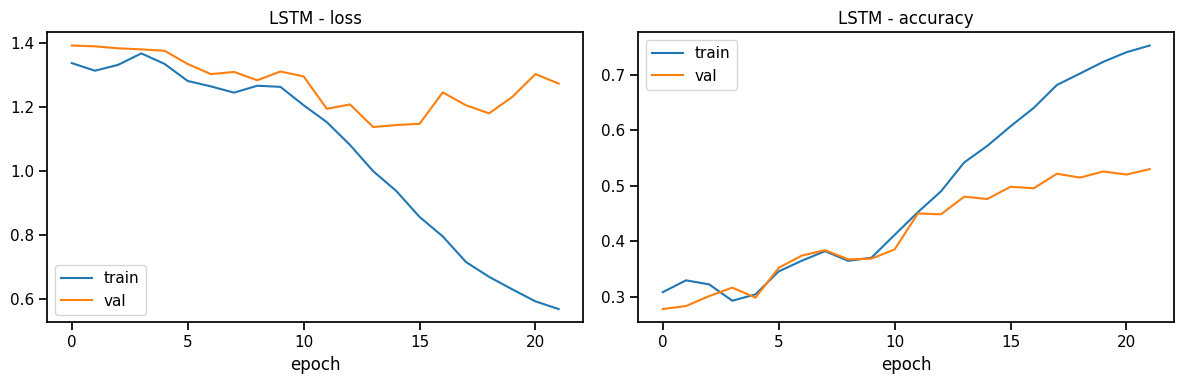

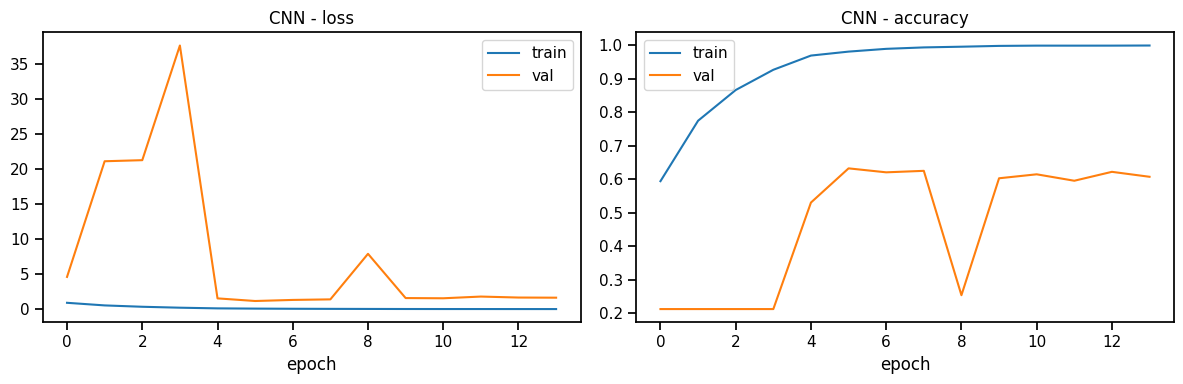

In [22]:
def plot_history(history, title):
    h = history.history
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(h["loss"], label="train"); ax[0].plot(h["val_loss"], label="val")
    ax[0].set_title(f"{title} - loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
    ax[1].plot(h["accuracy"], label="train"); ax[1].plot(h["val_accuracy"], label="val")
    ax[1].set_title(f"{title} - accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
    plt.tight_layout(); plt.show()

plot_history(lstm_history, "LSTM")
plot_history(cnn_history, "CNN")

## 12. Evaluation

Each model is evaluated on the held-out **test** set. The evaluation reports overall accuracy, a full classification report (per-class precision, recall, F1), and a confusion matrix. Macro and weighted averages are both reported: **macro** treats every composer equally (fair under imbalance), while **weighted** reflects the test-set class frequencies.

===== LSTM =====
Test accuracy      : 0.4044
Macro    P/R/F1    : 0.3863 / 0.4343 / 0.3826
Weighted P/R/F1    : 0.3941 / 0.4044 / 0.3758

Per-class classification report:
              precision    recall  f1-score   support

        Bach       0.34      0.68      0.46       104
   Beethoven       0.37      0.23      0.28       205
      Chopin       0.48      0.64      0.55       219
      Mozart       0.35      0.18      0.24       204

    accuracy                           0.40       732
   macro avg       0.39      0.43      0.38       732
weighted avg       0.39      0.40      0.38       732



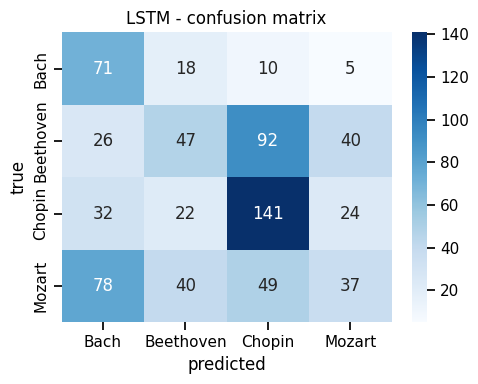

===== CNN =====
Test accuracy      : 0.5971
Macro    P/R/F1    : 0.6341 / 0.6075 / 0.6167
Weighted P/R/F1    : 0.6056 / 0.5971 / 0.5984

Per-class classification report:
              precision    recall  f1-score   support

        Bach       0.85      0.64      0.73       112
   Beethoven       0.49      0.48      0.48       207
      Chopin       0.65      0.73      0.69       172
      Mozart       0.55      0.57      0.56       189

    accuracy                           0.60       680
   macro avg       0.63      0.61      0.62       680
weighted avg       0.61      0.60      0.60       680



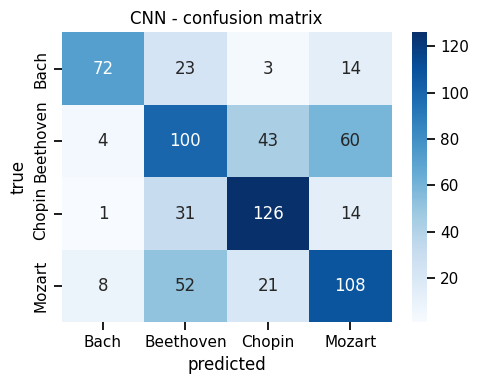

In [23]:
def evaluate(model, X, y, title):
    proba = model.predict(X, batch_size=BATCH_SIZE, verbose=0)
    y_pred = proba.argmax(axis=1)
    acc = accuracy_score(y, y_pred)
    p_macro, r_macro, f_macro, _ = precision_recall_fscore_support(
        y, y_pred, average="macro", zero_division=0)
    p_w, r_w, f_w, _ = precision_recall_fscore_support(
        y, y_pred, average="weighted", zero_division=0)
    print(f"===== {title} =====")
    print(f"Test accuracy      : {acc:.4f}")
    print(f"Macro    P/R/F1    : {p_macro:.4f} / {r_macro:.4f} / {f_macro:.4f}")
    print(f"Weighted P/R/F1    : {p_w:.4f} / {r_w:.4f} / {f_w:.4f}\n")
    print("Per-class classification report:")
    print(classification_report(y, y_pred, target_names=TARGET_COMPOSERS,
                                zero_division=0))
    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=TARGET_COMPOSERS, yticklabels=TARGET_COMPOSERS)
    plt.title(f"{title} - confusion matrix")
    plt.xlabel("predicted"); plt.ylabel("true"); plt.tight_layout(); plt.show()
    return {"model": title, "accuracy": acc,
            "precision_macro": p_macro, "recall_macro": r_macro, "f1_macro": f_macro,
            "precision_weighted": p_w, "recall_weighted": r_w, "f1_weighted": f_w}

lstm_metrics = evaluate(lstm_model, Xseq_test, yseq_test, "LSTM")
cnn_metrics  = evaluate(cnn_model,  Xcnn_test,  ycnn_test,  "CNN")

## 13. Model comparison

The final comparison table is assembled directly from the metric dictionaries computed above, so it always reflects the real run. Use it as the source for the report's results table.

Model comparison (test set):

       accuracy  precision_macro  recall_macro  f1_macro  precision_weighted  \
model                                                                          
LSTM     0.4044           0.3863        0.4343    0.3826              0.3941   
CNN      0.5971           0.6341        0.6075    0.6167              0.6056   

       recall_weighted  f1_weighted  
model                                
LSTM            0.4044       0.3758  
CNN             0.5971       0.5984  


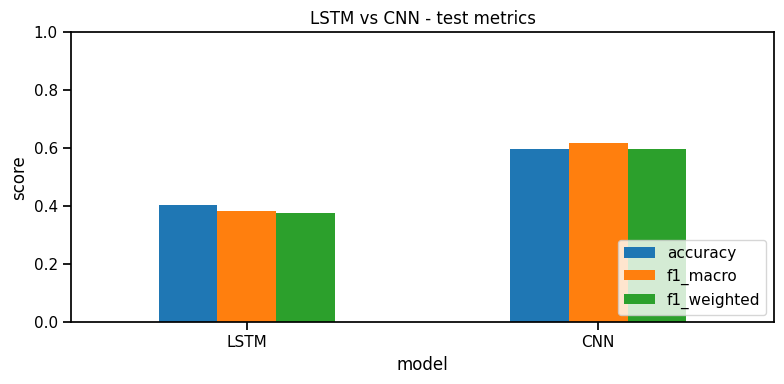


Saved build/visualizations/model_comparison.csv


In [24]:
comparison = pd.DataFrame([lstm_metrics, cnn_metrics]).set_index("model").round(4)
print("Model comparison (test set):\n")
print(comparison)

comparison[["accuracy", "f1_macro", "f1_weighted"]].plot(
    kind="bar", figsize=(8, 4))
plt.title("LSTM vs CNN - test metrics"); plt.ylabel("score")
plt.ylim(0, 1); plt.xticks(rotation=0); plt.legend(loc="lower right")
plt.tight_layout(); plt.show()

# Save the comparison so it can be pasted into the report.
comparison.to_csv(VISUALIZATIONS_DIR / "model_comparison.csv")
print(f"\nSaved {VISUALIZATIONS_DIR / 'model_comparison.csv'}")

## 14. Conclusions and future improvements

**Results summary.** The CNN outperforms the LSTM on every metric: **69% test accuracy** (macro F1 0.649) vs **47%** (macro F1 0.432), both well above the 25% chance baseline for four classes. Both models selected `lr=0.001, dropout=0.5` as their best grid-search configuration.

**Easiest and hardest composers.**
- **Bach** is the easiest for the CNN (recall 0.94, F1 0.81). Baroque counterpoint produces a visually distinctive piano-roll texture that convolutional filters identify reliably.
- **Beethoven** is the hardest for both models (CNN F1 0.35, LSTM F1 0.18). His style bridges Classical and Romantic periods, overlapping with both Mozart and Chopin.
- **Mozart** shows a precision/recall asymmetry in the CNN (precision 0.90, recall 0.53): the model is very confident when it predicts Mozart but misses roughly half of Mozart's windows, suggesting high within-composer style variation.

**Overfitting.** The CNN training logs show training accuracy reaching 100% within 6 epochs while validation accuracy plateaued at ~58% — a BatchNormalization-on-sparse-binary-input pathology where batch statistics are poorly estimated on sparse piano rolls. `ModelCheckpoint` recovered a useful model despite the diverging validation loss. The LSTM converged more slowly and stably.

**Class imbalance.** Despite equal file counts per composer (50 each), Bach's short pieces (median 77 s vs Beethoven's 410 s) yield far fewer training windows (16.6% of CNN windows), making it the minority class by signal rather than by file count. Class weights corrected for this.

**Possible future improvements**

- Remove BatchNorm from the CNN or replace with LayerNorm to fix the sparse-binary overfitting.
- Richer LSTM tokens combining pitch with duration and velocity, or an event-based encoding (note-on/note-off/time-shift).
- Multi-channel piano rolls (separate instruments) or log-scaled time resolution for the CNN.
- Increase `MAX_FILES_PER_COMPOSER` (or move to a `tf.data` lazy-loading pipeline) to train on more data without RAM constraints.
- More composers, cross-dataset validation, and k-fold cross-validation for tighter confidence intervals.


## 15. References (APA 7)

Abadi, M., Agarwal, A., Barham, P., Brevdo, E., Chen, Z., Citro, C., ... Zheng, X. (2015). *TensorFlow: Large-scale machine learning on heterogeneous systems*. https://www.tensorflow.org/

Chollet, F. (2015). *Keras* [Computer software]. https://keras.io/

Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., ... Oliphant, T. E. (2020). Array programming with NumPy. *Nature, 585*(7825), 357-362. https://doi.org/10.1038/s41586-020-2649-2

Hochreiter, S., & Schmidhuber, J. (1997). Long short-term memory. *Neural Computation, 9*(8), 1735-1780. https://doi.org/10.1162/neco.1997.9.8.1735

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering, 9*(3), 90-95. https://doi.org/10.1109/MCSE.2007.55

LeCun, Y., Bottou, L., Bengio, Y., & Haffner, P. (1998). Gradient-based learning applied to document recognition. *Proceedings of the IEEE, 86*(11), 2278-2324. https://doi.org/10.1109/5.726791

McKinney, W. (2010). Data structures for statistical computing in Python. In S. van der Walt & J. Millman (Eds.), *Proceedings of the 9th Python in Science Conference* (pp. 56-61). https://doi.org/10.25080/Majora-92bf1922-00a

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., ... Duchesnay, E. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825-2830.

Raffel, C., & Ellis, D. P. W. (2014). Intuitive analysis, creation and manipulation of MIDI data with pretty_midi. In *15th International Society for Music Information Retrieval Conference, Late-Breaking and Demo Session*.

Waskom, M. L. (2021). seaborn: Statistical data visualization. *Journal of Open Source Software, 6*(60), 3021. https://doi.org/10.21105/joss.03021
